# LumenY — 04: Probability Calibration

Fits an isotonic regression calibrator on the derived P(down) probabilities.

**What we calibrate:** The `np.interp()` derived probability — not the quantile models themselves.

**Splits:**
- Train: 2009-2020 → quantile models already trained on this
- Calibration: 2020-2022 → fit isotonic regressor here
- Test: 2022-2025 → final honest bucket table reported here only

**Output:** One isotonic calibrator per horizon saved to `backend/models/`

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.isotonic import IsotonicRegression

FEATURES_DIR = Path('../backend/data/features')
MODELS_DIR   = Path('../backend/models')

HORIZONS       = ['1H', '4H', '1D', '7D']
QUANTILES      = [0.10, 0.25, 0.50, 0.75, 0.90]
QUANTILE_NAMES = ['Q10', 'Q25', 'Q50', 'Q75', 'Q90']

print('Ready.')

Ready.


## 1. Load Dataset and Define Splits

In [2]:
df = pd.read_parquet(FEATURES_DIR / 'all_pairs_features_labels.parquet')

label_cols   = [f'label_{h}' for h in HORIZONS]
drop_cols    = label_cols + ['pair']
feature_cols = [c for c in df.columns if c not in drop_cols]

# Define splits by date
calib_start = '2020-01-01'
calib_end   = '2022-01-01'
test_start  = '2022-01-01'

df_calib = df[(df.index >= calib_start) & (df.index < calib_end)]
df_test  = df[df.index >= test_start]

print(f'Full dataset:  {len(df):,} rows')
print(f'Calibration:   {len(df_calib):,} rows ({calib_start} to {calib_end})')
print(f'Test:          {len(df_test):,} rows ({test_start} to end)')

Full dataset:  685,111 rows
Calibration:   80,679 rows (2020-01-01 to 2022-01-01)
Test:          169,152 rows (2022-01-01 to end)


## 2. Probability Derivation Function

Improved version — extrapolates beyond Q10/Q90 instead of hard-capping at 0.01/0.99.

In [3]:
def derive_p_down(q_vals: np.ndarray) -> float:
    """
    Derive P(down) from 5 quantile predictions [Q10, Q25, Q50, Q75, Q90].
    
    Improved: extrapolates beyond Q10/Q90 using the tail slope
    instead of hard-capping at 0.01/0.99.
    """
    qs   = np.array(QUANTILES)    # [0.10, 0.25, 0.50, 0.75, 0.90]
    vals = q_vals                  # [Q10_val, Q25_val, Q50_val, Q75_val, Q90_val]
    
    # If 0 is within the range of predicted quantiles — interpolate directly
    if vals[0] <= 0 <= vals[-1]:
        return float(np.interp(0, vals, qs))
    
    # If all quantiles are negative — extrapolate beyond Q90 using Q75-Q90 slope
    elif vals[-1] < 0:
        slope = (qs[-1] - qs[-2]) / (vals[-1] - vals[-2] + 1e-10)
        p_down = qs[-1] + slope * (0 - vals[-1])
        return float(np.clip(p_down, 0.90, 0.999))
    
    # If all quantiles are positive — extrapolate beyond Q10 using Q10-Q25 slope
    else:
        slope = (qs[1] - qs[0]) / (vals[1] - vals[0] + 1e-10)
        p_down = qs[0] + slope * (0 - vals[0])
        return float(np.clip(p_down, 0.001, 0.10))


def get_all_p_downs(df_subset, feature_cols, horizon):
    """
    Run all 5 quantile models on a dataset and derive P(down) for each row.
    Returns (p_downs, y_actual)
    """
    X = df_subset[feature_cols].ffill().bfill()
    y = df_subset[f'label_{horizon}'].values
    
    # Load and run all 5 quantile models
    q_preds = {}
    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        bundle = joblib.load(MODELS_DIR / f'model_{horizon}_Q{int(q*100)}.joblib')
        q_preds[q_name] = bundle['model'].predict(X)
    
    # Derive P(down) for each row
    p_downs = np.array([
        derive_p_down(np.array([q_preds[n][i] for n in QUANTILE_NAMES]))
        for i in range(len(X))
    ])
    
    return p_downs, y


print('Probability derivation functions ready.')

Probability derivation functions ready.


## 3. Fit Isotonic Calibrators on Calibration Set

In [4]:
calibrators = {}

for horizon in HORIZONS:
    print(f'Fitting calibrator for {horizon}...')
    
    # Get raw probabilities on calibration set
    p_downs_calib, y_calib = get_all_p_downs(df_calib, feature_cols, horizon)
    
    # Binary label: 1 if price went down
    y_binary = (y_calib < 0).astype(float)
    
    # Fit isotonic regression
    # increasing=True means: higher raw probability → higher calibrated probability
    iso = IsotonicRegression(out_of_bounds='clip', increasing=True)
    iso.fit(p_downs_calib, y_binary)
    
    calibrators[horizon] = iso
    
    # Quick check on calibration set itself
    p_cal = iso.predict(p_downs_calib)
    print(f'  Calibration set size: {len(p_downs_calib):,}')
    print(f'  Raw P(down) range:        [{p_downs_calib.min():.3f}, {p_downs_calib.max():.3f}]')
    print(f'  Calibrated P(down) range: [{p_cal.min():.3f}, {p_cal.max():.3f}]')
    
    # Save calibrator
    joblib.dump(iso, MODELS_DIR / f'calibrator_{horizon}.joblib')
    print(f'  Saved: calibrator_{horizon}.joblib')

print('\nAll calibrators fitted and saved.')

Fitting calibrator for 1H...
  Calibration set size: 80,679
  Raw P(down) range:        [0.001, 0.999]
  Calibrated P(down) range: [0.005, 0.996]
  Saved: calibrator_1H.joblib
Fitting calibrator for 4H...
  Calibration set size: 80,679
  Raw P(down) range:        [0.001, 0.999]
  Calibrated P(down) range: [0.017, 0.986]
  Saved: calibrator_4H.joblib
Fitting calibrator for 1D...
  Calibration set size: 80,679
  Raw P(down) range:        [0.001, 0.999]
  Calibrated P(down) range: [0.010, 0.992]
  Saved: calibrator_1D.joblib
Fitting calibrator for 7D...
  Calibration set size: 80,679
  Raw P(down) range:        [0.200, 0.755]
  Calibrated P(down) range: [0.000, 1.000]
  Saved: calibrator_7D.joblib

All calibrators fitted and saved.


## 4. Evaluate on Test Set (2022-2025)

This is the honest final evaluation — data the calibrator has never seen.

In [5]:
def bucket_analysis(p_downs_raw, p_downs_cal, y_actual, horizon):
    """
    Compare raw vs calibrated bucket accuracy on test set.
    """
    correct_raw = np.where(p_downs_raw > 0.5, y_actual < 0, y_actual > 0)
    correct_cal = np.where(p_downs_cal > 0.5, y_actual < 0, y_actual > 0)
    
    p_dom_raw = np.where(p_downs_raw > 0.5, p_downs_raw, 1 - p_downs_raw)
    p_dom_cal = np.where(p_downs_cal > 0.5, p_downs_cal, 1 - p_downs_cal)
    
    buckets = [(0.50, 0.55), (0.55, 0.60), (0.60, 0.65),
               (0.65, 0.70), (0.70, 0.80), (0.80, 0.90), (0.90, 1.00)]
    
    print(f'\nHorizon: {horizon}')
    print(f'  {"Bucket":<12} {"Raw pred":<12} {"Raw actual":<13} {"Cal pred":<12} {"Cal actual":<13} {"Count":<8} {"Status"}')
    print(f'  {"-"*80}')
    
    for low, high in buckets:
        mask_raw = (p_dom_raw >= low) & (p_dom_raw < high)
        mask_cal = (p_dom_cal >= low) & (p_dom_cal < high)
        
        if mask_cal.sum() < 20:
            continue
        
        raw_pred   = p_dom_raw[mask_raw].mean() if mask_raw.sum() > 0 else 0
        raw_actual = correct_raw[mask_raw].mean() if mask_raw.sum() > 0 else 0
        cal_pred   = p_dom_cal[mask_cal].mean()
        cal_actual = correct_cal[mask_cal].mean()
        count      = mask_cal.sum()
        gap        = abs(cal_actual - cal_pred)
        status     = 'OK' if gap < 0.05 else 'NEEDS WORK'
        
        print(f'  {low:.0%}-{high:.0%}      '
              f'{raw_pred:.1%}        {raw_actual:.1%}         '
              f'{cal_pred:.1%}        {cal_actual:.1%}         '
              f'{count:<8} {status}')


print('Running bucket analysis on TEST SET (2022-2025)...\n')
print('=' * 80)

test_results = {}

for horizon in HORIZONS:
    # Get raw probabilities on test set
    p_downs_raw, y_test = get_all_p_downs(df_test, feature_cols, horizon)
    
    # Apply calibrator
    iso = calibrators[horizon]
    p_downs_cal = iso.predict(p_downs_raw)
    
    bucket_analysis(p_downs_raw, p_downs_cal, y_test, horizon)
    test_results[horizon] = (p_downs_raw, p_downs_cal, y_test)

Running bucket analysis on TEST SET (2022-2025)...


Horizon: 1H
  Bucket       Raw pred     Raw actual    Cal pred     Cal actual    Count    Status
  --------------------------------------------------------------------------------
  50%-55%      52.4%        52.7%         52.6%        51.6%         16949    OK
  55%-60%      57.4%        61.0%         57.3%        56.3%         16628    OK
  60%-65%      62.4%        66.0%         62.4%        62.0%         19285    OK
  65%-70%      67.4%        70.7%         67.6%        66.6%         15149    OK
  70%-80%      75.6%        78.9%         73.5%        73.0%         21178    OK
  80%-90%      84.8%        90.1%         86.0%        85.9%         30837    OK
  90%-100%      97.2%        98.3%         97.1%        97.1%         49126    OK

Horizon: 4H
  Bucket       Raw pred     Raw actual    Cal pred     Cal actual    Count    Status
  --------------------------------------------------------------------------------
  50%-55%      52.

## 5. Calibration Curves — Before vs After

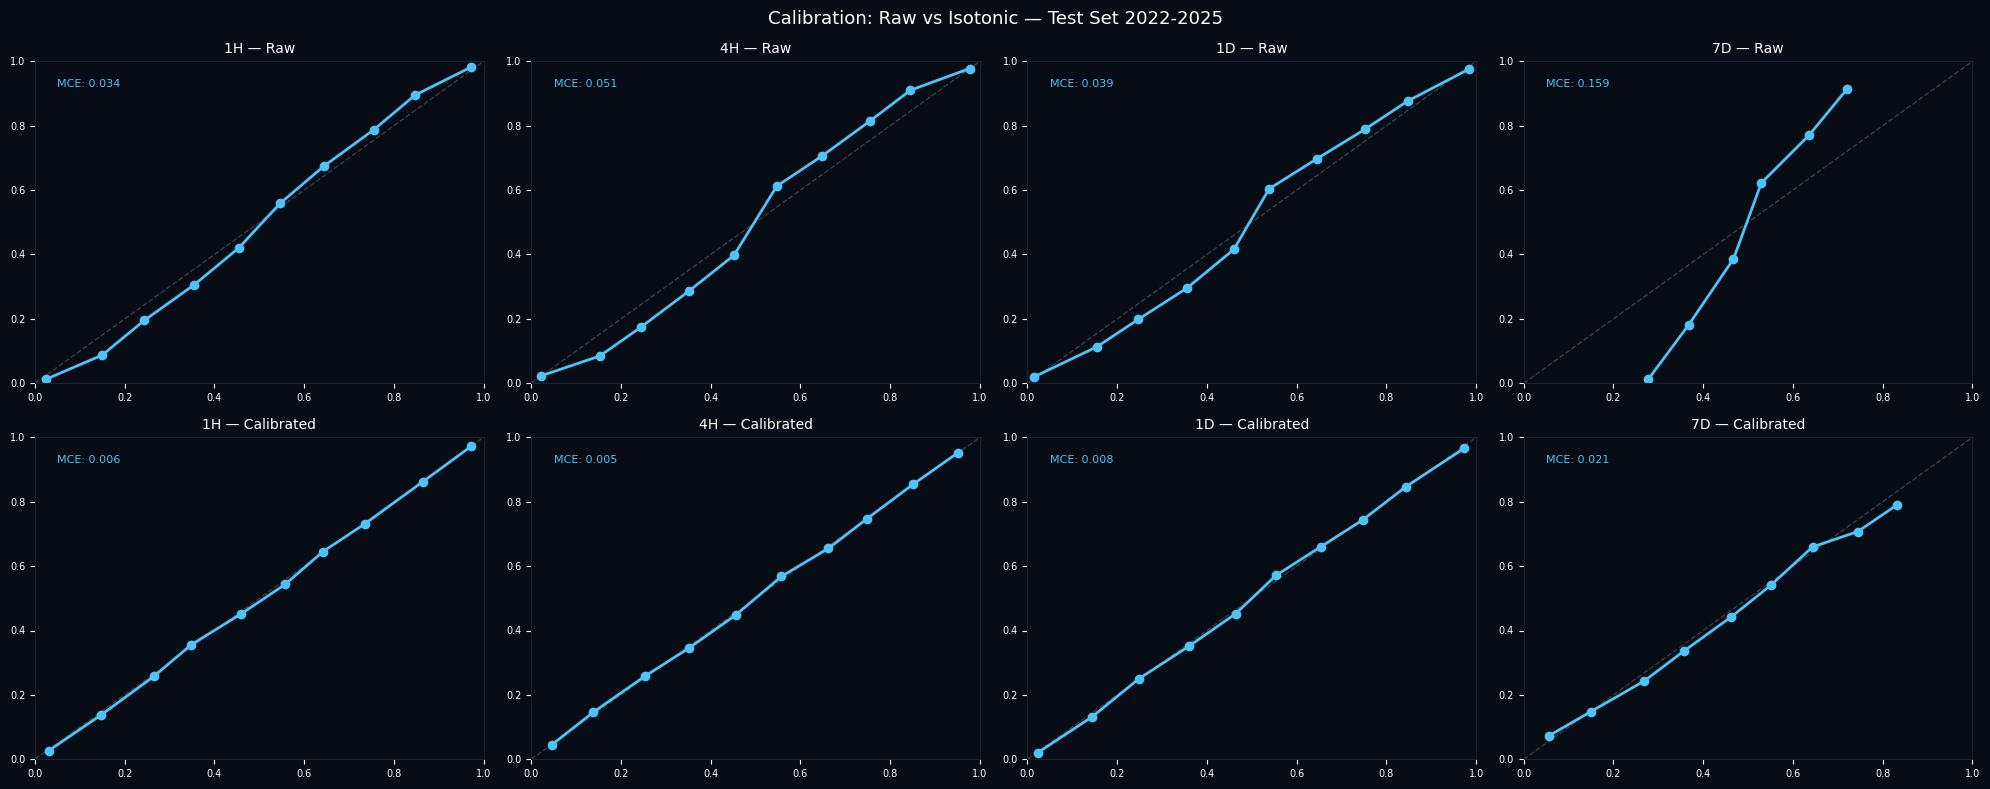

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.patch.set_facecolor('#080c14')

for col, horizon in enumerate(HORIZONS):
    p_raw, p_cal, y_test = test_results[horizon]
    y_binary = (y_test < 0).astype(float)
    
    for row, (p_vals, title) in enumerate([(p_raw, 'Raw'), (p_cal, 'Calibrated')]):
        ax = axes[row][col]
        ax.set_facecolor('#080c14')
        
        # Bucket the probabilities
        bins = np.linspace(0, 1, 11)
        bin_preds, bin_actuals = [], []
        
        for i in range(len(bins)-1):
            mask = (p_vals >= bins[i]) & (p_vals < bins[i+1])
            if mask.sum() > 30:
                bin_preds.append(p_vals[mask].mean())
                bin_actuals.append(y_binary[mask].mean())
        
        ax.plot([0,1],[0,1],'--',color=(1,1,1,0.2),linewidth=1)
        ax.plot(bin_preds, bin_actuals, 'o-', color='#4fc3f7', linewidth=2, markersize=6)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_title(f'{horizon} — {title}', color='white', fontsize=10)
        ax.tick_params(colors='white', labelsize=7)
        for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
        
        if bin_preds:
            mce = np.mean(np.abs(np.array(bin_preds) - np.array(bin_actuals)))
            ax.text(0.05, 0.92, f'MCE: {mce:.3f}', transform=ax.transAxes,
                    color='#4fc3f7', fontsize=8)

plt.suptitle('Calibration: Raw vs Isotonic — Test Set 2022-2025', color='white', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# Signal frequency analysis — TEST SET ONLY (2022-2025)
# How often does the model produce actionable signals?

print('Signal Frequency Analysis — Test Set 2022-2025')
print('=' * 60)

thresholds = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

for horizon in HORIZONS:
    p_raw, p_cal, y_test = test_results[horizon]
    
    # Dominant probability (always > 0.5)
    p_dom = np.where(p_cal > 0.5, p_cal, 1 - p_cal)
    
    print(f'\nHorizon: {horizon} ({len(p_dom):,} predictions)')
    print(f'  {"Threshold":<12} {"Frequency":<12} {"Count":<12} {"Actual acc"}')
    print(f'  {"-"*48}')
    
    for thresh in thresholds:
        mask     = p_dom >= thresh
        count    = mask.sum()
        freq     = count / len(p_dom)
        
        if count > 20:
            correct  = np.where(
                p_cal[mask] > 0.5,
                y_test[mask] < 0,
                y_test[mask] > 0
            ).mean()
        else:
            correct = float('nan')
        
        print(f'  >={thresh:.0%}        {freq:.1%}         {count:<12} {correct:.1%}' if count > 20 else
              f'  >={thresh:.0%}        {freq:.1%}         {count:<12} insufficient data')

Signal Frequency Analysis — Test Set 2022-2025

Horizon: 1H (169,152 predictions)
  Threshold    Frequency    Count        Actual acc
  ------------------------------------------------
  >=55%        90.0%         152203       79.5%
  >=60%        80.1%         135575       82.4%
  >=65%        68.7%         116290       85.8%
  >=70%        59.8%         101141       88.7%
  >=75%        50.9%         86115        91.6%
  >=80%        47.3%         79963        92.8%

Horizon: 4H (169,152 predictions)
  Threshold    Frequency    Count        Actual acc
  ------------------------------------------------
  >=55%        95.3%         161284       81.4%
  >=60%        91.6%         155016       82.3%
  >=65%        83.7%         141638       84.3%
  >=70%        68.9%         116533       88.0%
  >=75%        58.2%         98455        90.8%
  >=80%        52.5%         88779        92.3%

Horizon: 1D (169,152 predictions)
  Threshold    Frequency    Count        Actual acc
  ------------

In [9]:
# Regime analysis — does accuracy hold during high volatility and trend reversals?

import pandas as pd
import numpy as np

print('Regime Analysis — Test Set 2022-2025')
print('=' * 60)

# Load 1H close prices for volatility/regime computation
df_1h_all = {}
for pair in ['EURUSD', 'GBPUSD', 'USDJPY']:
    df_pair = pd.read_parquet(FEATURES_DIR / f'../processed/{pair}_1H.parquet')
    df_1h_all[pair] = df_pair

# Use EURUSD as market proxy
eurusd = df_1h_all['EURUSD']
eurusd_test = eurusd[eurusd.index >= '2022-01-01']

log_ret = np.log(eurusd_test['close'] / eurusd_test['close'].shift(1))

# Rolling 24H realized volatility
rvol_24 = log_ret.rolling(24).std()

# Volatility regimes
vol_median = rvol_24.median()
vol_75     = rvol_24.quantile(0.75)
vol_90     = rvol_24.quantile(0.90)

print(f'\nEURUSD 1H Volatility percentiles (test set):')
print(f'  Median: {vol_median:.6f}')
print(f'  75th:   {vol_75:.6f}')
print(f'  90th:   {vol_90:.6f}')

# Trend reversal detection
# A reversal day = 24H return flips sign vs previous 24H
ret_24h = np.log(eurusd_test['close'] / eurusd_test['close'].shift(24))
prev_ret_24h = ret_24h.shift(24)
reversal_mask = (np.sign(ret_24h) != np.sign(prev_ret_24h))

print(f'\nReversal bars: {reversal_mask.sum():,} / {len(reversal_mask):,} ({reversal_mask.mean():.1%})')

# Now analyze model accuracy by regime
# Focus on 1H and 1D horizons at >=65% threshold
for horizon in ['1H', '1D']:
    print(f'\n{"="*55}')
    print(f'Horizon: {horizon} — Accuracy by Regime (>=65% signals only)')
    print(f'{"="*55}')
    
    p_raw, p_cal, y_test = test_results[horizon]
    p_dom = np.where(p_cal > 0.5, p_cal, 1 - p_cal)
    
    # Align volatility and reversal masks to test_results index
    # test_results index matches df_test index
    df_test_index = df_test.index
    
    rvol_aligned    = rvol_24.reindex(df_test_index, method='ffill')
    reversal_aligned = reversal_mask.reindex(df_test_index, fill_value=False)
    
    # Since test_results are per-pair combined, we use all pairs
    # Repeat regime arrays for all 7 pairs
    n_pairs = 7
    rvol_rep     = np.tile(rvol_aligned.values, n_pairs)[:len(p_cal)]
    reversal_rep = np.tile(reversal_aligned.values, n_pairs)[:len(p_cal)]
    
    signal_mask = p_dom >= 0.65
    
    # Normal volatility
    low_vol  = signal_mask & (rvol_rep < vol_median)
    mid_vol  = signal_mask & (rvol_rep >= vol_median) & (rvol_rep < vol_75)
    high_vol = signal_mask & (rvol_rep >= vol_75) & (rvol_rep < vol_90)
    ext_vol  = signal_mask & (rvol_rep >= vol_90)
    
    # Reversal vs trending
    reversal = signal_mask & reversal_rep
    trending = signal_mask & ~reversal_rep
    
    correct = np.where(p_cal > 0.5, y_test < 0, y_test > 0)
    
    print(f'\n  Volatility regime:')
    print(f'  {"Regime":<20} {"Count":<10} {"Accuracy"}')
    print(f'  {"-"*40}')
    for label, mask in [
        ('Low vol',    low_vol),
        ('Mid vol',    mid_vol),
        ('High vol',   high_vol),
        ('Extreme vol', ext_vol),
    ]:
        if mask.sum() > 50:
            acc = correct[mask].mean()
            print(f'  {label:<20} {mask.sum():<10} {acc:.1%}')
    
    print(f'\n  Trend regime:')
    print(f'  {"Regime":<20} {"Count":<10} {"Accuracy"}')
    print(f'  {"-"*40}')
    for label, mask in [
        ('Trending',   trending),
        ('Reversal',   reversal),
    ]:
        if mask.sum() > 50:
            acc = correct[mask].mean()
            flag = '' if acc > 0.60 else '  ← DROPS SIGNIFICANTLY'
            print(f'  {label:<20} {mask.sum():<10} {acc:.1%}{flag}')

Regime Analysis — Test Set 2022-2025

EURUSD 1H Volatility percentiles (test set):
  Median: 0.000873
  75th:   0.001176
  90th:   0.001636

Reversal bars: 12,161 / 24,393 (49.9%)

Horizon: 1H — Accuracy by Regime (>=65% signals only)

  Volatility regime:
  Regime               Count      Accuracy
  ----------------------------------------
  Low vol              57204      85.9%
  Mid vol              29339      85.5%
  High vol             17629      85.6%
  Extreme vol          12000      86.1%

  Trend regime:
  Regime               Count      Accuracy
  ----------------------------------------
  Trending             58328      85.9%
  Reversal             57962      85.7%

Horizon: 1D — Accuracy by Regime (>=65% signals only)

  Volatility regime:
  Regime               Count      Accuracy
  ----------------------------------------
  Low vol              51796      84.0%
  Mid vol              25829      84.1%
  High vol             16175      83.4%
  Extreme vol          11011   

In [10]:
# True test — single pair, non-overlapping windows
print('True Accuracy Test — EURUSD only, non-overlapping windows')
print('=' * 60)

df_eurusd_test = df_test[df_test['pair'] == 'EURUSD'].copy()

for horizon, step in [('1H', 1), ('4H', 4), ('1D', 24), ('7D', 168)]:
    print(f'\nHorizon: {horizon} (step={step}, non-overlapping)')
    
    # Non-overlapping rows only
    df_nonoverlap = df_eurusd_test.iloc[::step]
    
    # Get raw probabilities
    X = df_nonoverlap[feature_cols].ffill().bfill()
    y = df_nonoverlap[f'label_{horizon}'].values
    
    # Run all 5 quantile models
    q_preds = {}
    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        bundle = joblib.load(MODELS_DIR / f'model_{horizon}_Q{int(q*100)}.joblib')
        q_preds[q_name] = bundle['model'].predict(X)
    
    # Derive and calibrate P(down)
    iso = calibrators[horizon]
    p_downs_raw = np.array([
        derive_p_down(np.array([q_preds[n][i] for n in QUANTILE_NAMES]))
        for i in range(len(X))
    ])
    p_cal = iso.predict(p_downs_raw)
    p_dom = np.where(p_cal > 0.5, p_cal, 1 - p_cal)
    correct = np.where(p_cal > 0.5, y < 0, y > 0)
    
    print(f'  Total predictions: {len(p_cal):,}')
    print(f'  {"Threshold":<12} {"Frequency":<12} {"Count":<12} {"Actual acc"}')
    print(f'  {"-"*48}')
    
    for thresh in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
        mask  = p_dom >= thresh
        count = mask.sum()
        freq  = count / len(p_dom)
        if count > 20:
            acc = correct[mask].mean()
            flag = '' if acc < 0.75 else '  ← suspiciously high'
            print(f'  >={thresh:.0%}        {freq:.1%}         {count:<12} {acc:.1%}{flag}')
        else:
            print(f'  >={thresh:.0%}        {freq:.1%}         {count:<12} insufficient data')

True Accuracy Test — EURUSD only, non-overlapping windows

Horizon: 1H (step=1, non-overlapping)
  Total predictions: 24,225
  Threshold    Frequency    Count        Actual acc
  ------------------------------------------------
  >=55%        89.7%         21720        79.8%  ← suspiciously high
  >=60%        79.7%         19318        82.6%  ← suspiciously high
  >=65%        68.2%         16520        86.1%  ← suspiciously high
  >=70%        59.2%         14348        88.9%  ← suspiciously high
  >=75%        50.5%         12233        91.7%  ← suspiciously high
  >=80%        47.1%         11411        92.8%  ← suspiciously high

Horizon: 4H (step=4, non-overlapping)
  Total predictions: 6,057
  Threshold    Frequency    Count        Actual acc
  ------------------------------------------------
  >=55%        95.7%         5798         81.1%  ← suspiciously high
  >=60%        91.8%         5562         82.1%  ← suspiciously high
  >=65%        83.9%         5083         84.2%  ← 

In [11]:
# TEST 1: Economic Significance
# Does the model produce moves large enough to be tradeable after spread/slippage?

print('Economic Significance Test — Test Set 2022-2025')
print('=' * 60)

# Typical FX spreads (in % terms)
SPREADS = {
    'EURUSD': 0.0002,  # 0.02% = 2 pips
    'GBPUSD': 0.0003,
    'USDJPY': 0.0002,
    'USDCHF': 0.0003,
    'AUDUSD': 0.0003,
    'USDCAD': 0.0003,
    'NZDUSD': 0.0004,
}
AVG_SPREAD = np.mean(list(SPREADS.values()))

for horizon in HORIZONS:
    print(f'\nHorizon: {horizon}')
    print(f'  {"Threshold":<12} {"Avg |move|":<15} {"After spread":<15} {"Tradeable?":<12} {"Win rate"}')
    print(f'  {"-"*65}')
    
    p_raw, p_cal, y_test = test_results[horizon]
    p_dom = np.where(p_cal > 0.5, p_cal, 1 - p_cal)
    correct = np.where(p_cal > 0.5, y_test < 0, y_test > 0)
    
    for thresh in [0.60, 0.65, 0.70, 0.75, 0.80]:
        mask = p_dom >= thresh
        if mask.sum() < 20:
            continue
        
        # Average absolute actual move in high confidence predictions
        avg_move    = np.abs(y_test[mask]).mean() * 100  # in %
        after_spread = avg_move - (AVG_SPREAD * 100)
        win_rate    = correct[mask].mean()
        
        # Expected value per trade = win_rate * avg_move - (1-win_rate) * avg_move - spread
        ev = (win_rate * avg_move) - ((1 - win_rate) * avg_move) - (AVG_SPREAD * 100)
        tradeable = 'YES' if ev > 0 else 'NO'
        
        print(f'  >={thresh:.0%}        {avg_move:.4f}%        {after_spread:.4f}%        {tradeable:<12} {win_rate:.1%}  (EV: {ev:+.4f}%)')

Economic Significance Test — Test Set 2022-2025

Horizon: 1H
  Threshold    Avg |move|      After spread    Tradeable?   Win rate
  -----------------------------------------------------------------
  >=60%        0.0897%        0.0612%        YES          82.4%  (EV: +0.0296%)
  >=65%        0.0930%        0.0644%        YES          85.8%  (EV: +0.0380%)
  >=70%        0.0967%        0.0681%        YES          88.7%  (EV: +0.0462%)
  >=75%        0.0999%        0.0713%        YES          91.6%  (EV: +0.0544%)
  >=80%        0.1018%        0.0733%        YES          92.8%  (EV: +0.0586%)

Horizon: 4H
  Threshold    Avg |move|      After spread    Tradeable?   Win rate
  -----------------------------------------------------------------
  >=60%        0.1752%        0.1466%        YES          82.3%  (EV: +0.0848%)
  >=65%        0.1811%        0.1525%        YES          84.3%  (EV: +0.0955%)
  >=70%        0.1945%        0.1659%        YES          88.0%  (EV: +0.1192%)
  >=75%     

In [ ]:
# Add this at the end of the economic significance cell

print('\n\nSANITY CHECK — EURUSD only, non-overlapping')
print('=' * 60)

df_eurusd_test = df_test[df_test['pair'] == 'EURUSD'].copy()

for horizon, step in [('1H', 1), ('4H', 4), ('1D', 24), ('7D', 168)]:
    print(f'\nHorizon: {horizon}')
    
    df_nonoverlap = df_eurusd_test.iloc[::step]
    X = df_nonoverlap[feature_cols].ffill()
    y = df_nonoverlap[f'label_{horizon}'].values
    
    q_preds = {}
    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        bundle = joblib.load(MODELS_DIR / f'model_{horizon}_Q{int(q*100)}.joblib')
        q_preds[q_name] = bundle['model'].predict(X)
    
    p_downs_raw = np.array([
        derive_p_down(np.array([q_preds[n][i] for n in QUANTILE_NAMES]))
        for i in range(len(X))
    ])
    p_cal = iso.predict(p_downs_raw)
    p_dom = np.where(p_cal > 0.5, p_cal, 1 - p_cal)
    correct = np.where(p_cal > 0.5, y < 0, y > 0)
    
    print(f'  {"Threshold":<12} {"Avg |move|":<15} {"After spread":<15} {"Tradeable?":<12} {"Win rate"}')
    print(f'  {"-"*65}')
    
    for thresh in [0.60, 0.65, 0.70, 0.75, 0.80]:
        mask = p_dom >= thresh
        if mask.sum() < 20:
            continue
        avg_move     = np.abs(y[mask]).mean() * 100
        after_spread = avg_move - (AVG_SPREAD * 100)
        win_rate     = correct[mask].mean()
        ev           = (win_rate * avg_move) - ((1 - win_rate) * avg_move) - (AVG_SPREAD * 100)
        tradeable    = 'YES' if ev > 0 else 'NO'
        print(f'  >={thresh:.0%}        {avg_move:.4f}%        {after_spread:.4f}%        {tradeable:<12} {win_rate:.1%}  (EV: {ev:+.4f}%)')



SANITY CHECK — EURUSD only, non-overlapping

Horizon: 1H
  Threshold    Avg |move|      After spread    Tradeable?   Win rate
  -----------------------------------------------------------------
  >=60%        0.0708%        0.0423%        YES          78.9%  (EV: +0.0124%)
  >=65%        0.0715%        0.0430%        YES          80.4%  (EV: +0.0149%)
  >=70%        0.0731%        0.0445%        YES          82.7%  (EV: +0.0193%)
  >=75%        0.0752%        0.0466%        YES          86.1%  (EV: +0.0257%)
  >=80%        0.0761%        0.0475%        YES          87.0%  (EV: +0.0278%)

Horizon: 4H
  Threshold    Avg |move|      After spread    Tradeable?   Win rate
  -----------------------------------------------------------------
  >=60%        0.1451%        0.1166%        YES          81.4%  (EV: +0.0625%)
  >=65%        0.1473%        0.1187%        YES          82.3%  (EV: +0.0666%)
  >=70%        0.1512%        0.1226%        YES          83.6%  (EV: +0.0729%)
  >=75%       

Yearly Reliability Analysis...


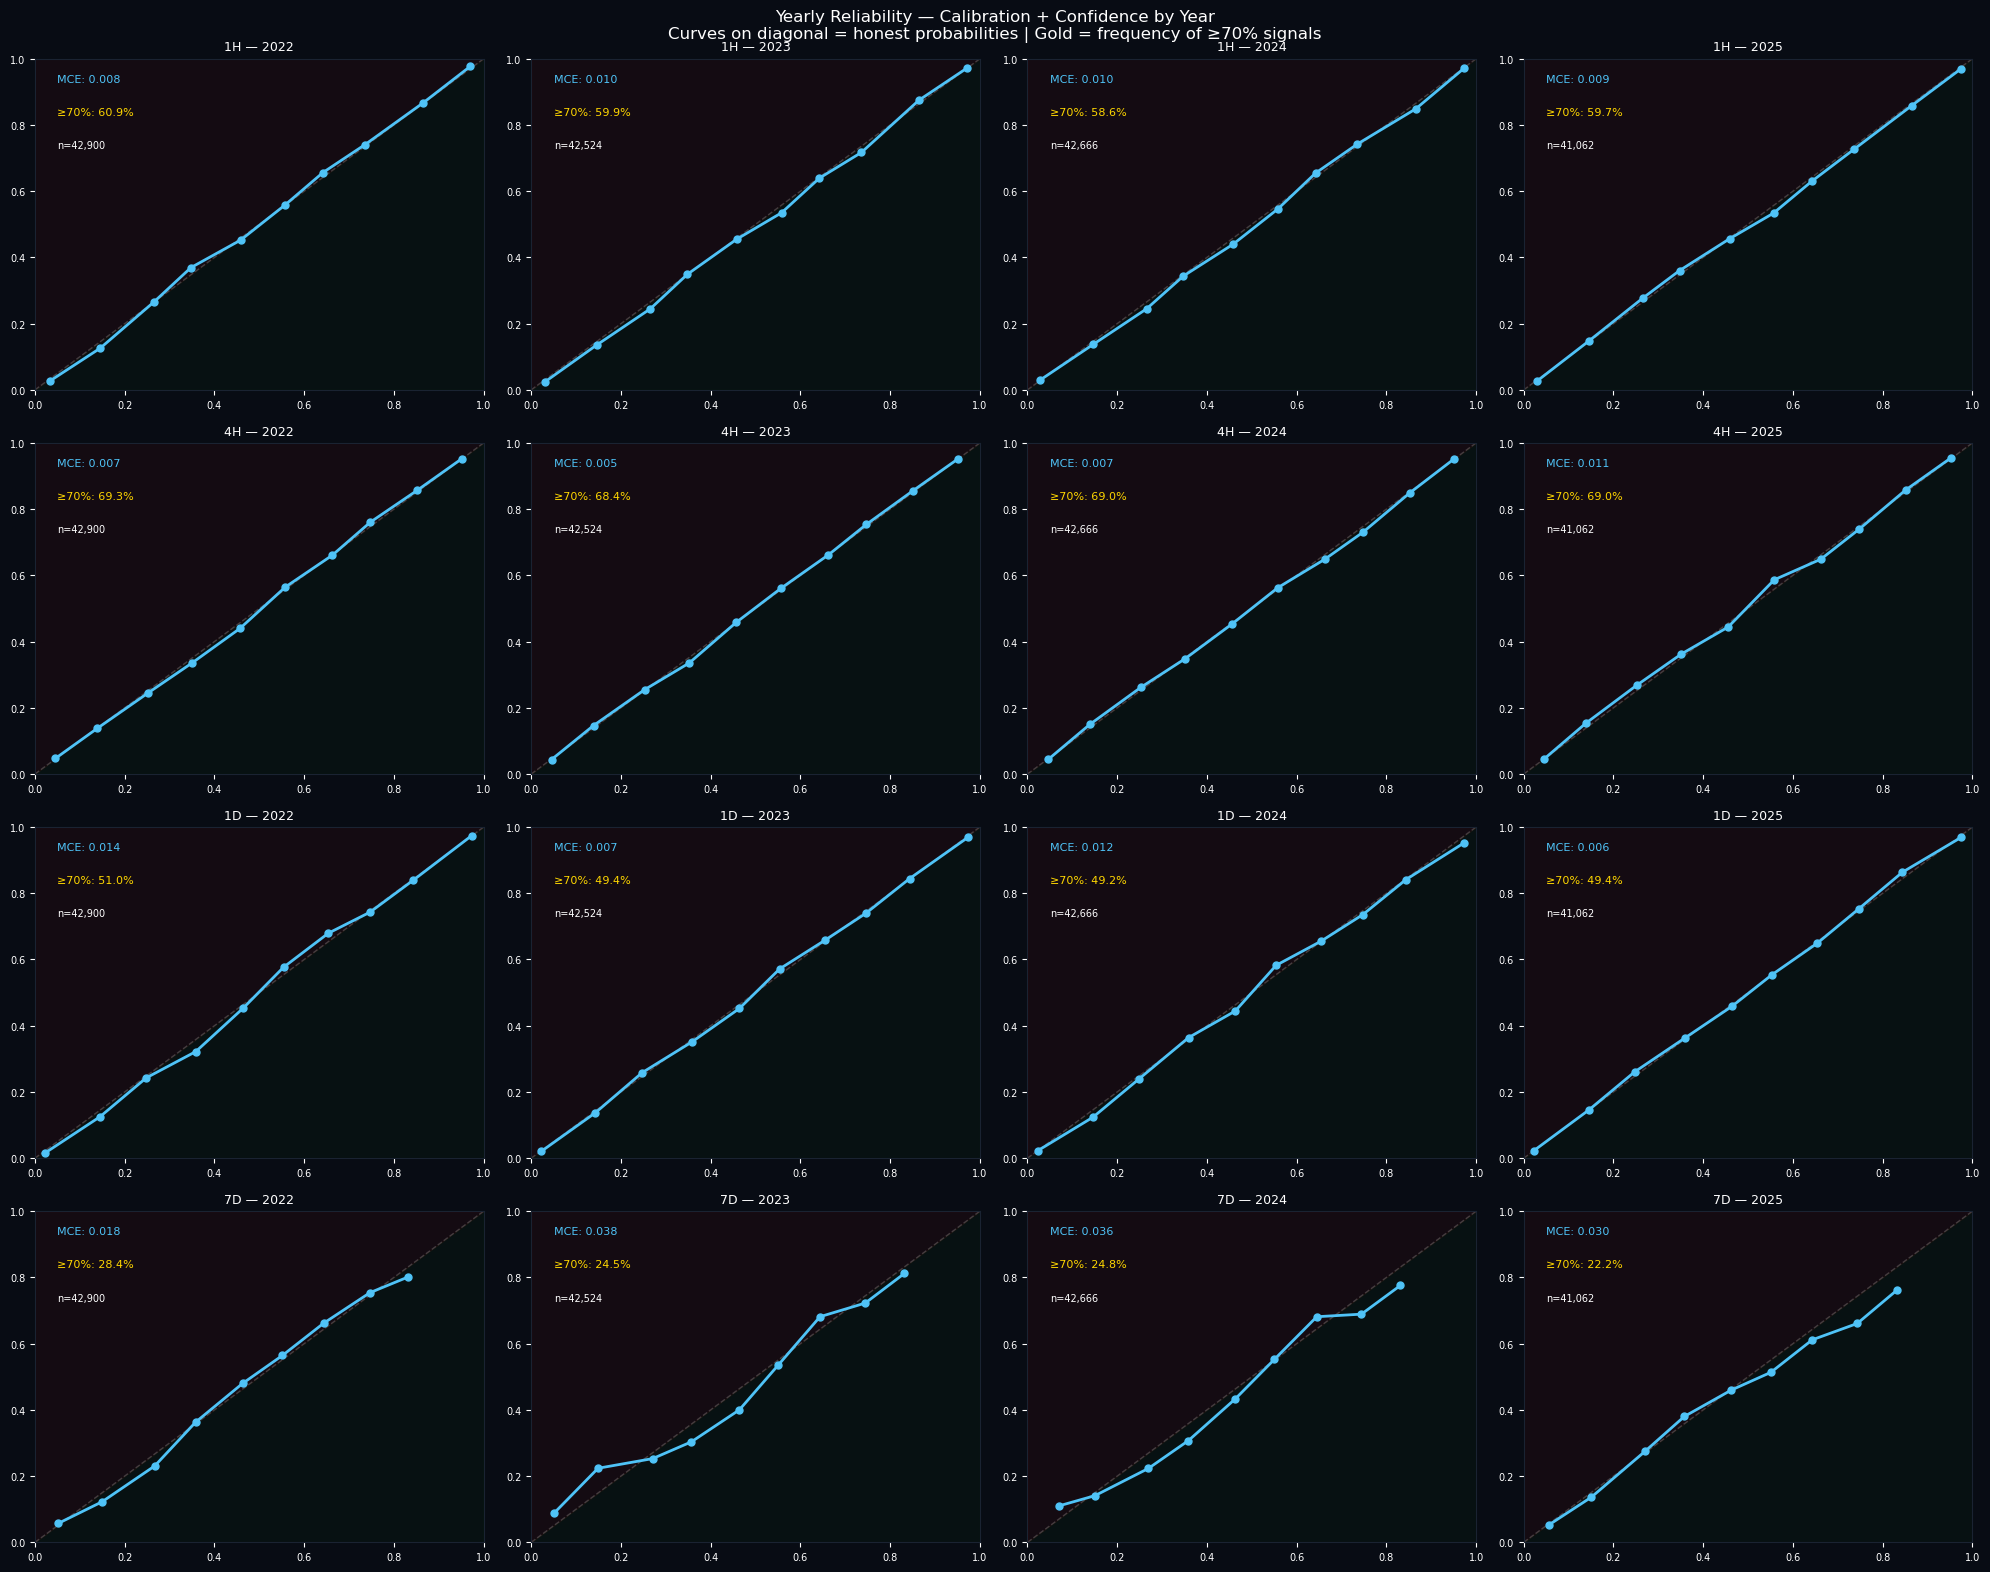


Horizon  Year   MCE      ≥65% freq    ≥70% freq    ≥70% acc
-------------------------------------------------------
1H       2022   0.008    69.7%        60.9%        88.8%
1H       2023   0.010    68.8%        59.9%        89.0%
1H       2024   0.010    68.0%        58.6%        88.4%
1H       2025   0.009    68.5%        59.7%        88.4%
4H       2022   0.007    84.0%        69.3%        88.4%
4H       2023   0.005    83.3%        68.4%        88.1%
4H       2024   0.007    83.8%        69.0%        87.6%
4H       2025   0.011    83.8%        69.0%        87.9%
1D       2022   0.014    63.3%        51.0%        88.5%
1D       2023   0.007    61.6%        49.4%        88.3%
1D       2024   0.012    61.9%        49.2%        87.8%
1D       2025   0.006    61.3%        49.4%        88.1%
7D       2022   0.018    44.6%        28.4%        79.1%
7D       2023   0.038    41.3%        24.5%        76.0%
7D       2024   0.036    41.8%        24.8%        76.6%
7D       2025   0.030    38.

In [14]:
# Yearly reliability diagram — calibration + confidence by year
# If curves stay on diagonal across all years → structural edge
# If certain years break down → regime dependent

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print('Yearly Reliability Analysis...')

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#080c14')

years = [2022, 2023, 2024, 2025]
horizons_to_plot = ['1H', '4H', '1D', '7D']

for h_idx, horizon in enumerate(horizons_to_plot):
    
    # Get full test set predictions
    X_test = df_test[feature_cols].ffill()
    y_test_full = df_test[f'label_{horizon}'].values
    
    q_preds = {}
    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        bundle = joblib.load(MODELS_DIR / f'model_{horizon}_Q{int(q*100)}.joblib')
        q_preds[q_name] = bundle['model'].predict(X_test)
    
    p_downs_raw = np.array([
        derive_p_down(np.array([q_preds[n][i] for n in QUANTILE_NAMES]))
        for i in range(len(X_test))
    ])
    
    iso = calibrators[horizon]
    p_cal = iso.predict(p_downs_raw)
    
    for y_idx, year in enumerate(years):
        ax = fig.add_subplot(len(horizons_to_plot), len(years), 
                             h_idx * len(years) + y_idx + 1)
        ax.set_facecolor('#080c14')
        
        # Filter to this year
        year_mask = df_test.index.year == year
        p_year    = p_cal[year_mask]
        y_year    = y_test_full[year_mask]
        y_binary  = (y_year < 0).astype(float)
        
        if len(p_year) < 100:
            ax.text(0.5, 0.5, 'Insufficient\ndata', 
                    ha='center', va='center', color='white',
                    transform=ax.transAxes)
            continue
        
        # Reliability diagram
        bins = np.linspace(0, 1, 11)
        bin_preds, bin_actuals, bin_counts = [], [], []
        
        for i in range(len(bins)-1):
            mask = (p_year >= bins[i]) & (p_year < bins[i+1])
            if mask.sum() > 30:
                bin_preds.append(p_year[mask].mean())
                bin_actuals.append(y_binary[mask].mean())
                bin_counts.append(mask.sum())
        
        if not bin_preds:
            continue
            
        # Calibration curve
        ax.plot([0,1],[0,1],'--',color=(1,1,1,0.2),linewidth=1)
        ax.plot(bin_preds, bin_actuals, 'o-', 
                color='#4fc3f7', linewidth=2, markersize=5)
        
        # Shade overconfident vs underconfident regions
        ax.fill_between([0,1],[0,1],[1,1], alpha=0.05, color='red')     # overconfident
        ax.fill_between([0,1],[0,0],[0,1], alpha=0.05, color='green')   # underconfident
        
        # MCE for this year
        mce = np.mean(np.abs(np.array(bin_preds) - np.array(bin_actuals)))
        
        # Confidence distribution (histogram inset)
        p_dom = np.where(p_year > 0.5, p_year, 1 - p_year)
        high_conf = (p_dom >= 0.70).mean()
        
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_title(f'{horizon} — {year}', color='white', fontsize=9)
        ax.tick_params(colors='white', labelsize=7)
        for spine in ax.spines.values(): 
            spine.set_edgecolor('#1a2332')
        
        # Key stats
        ax.text(0.05, 0.93, f'MCE: {mce:.3f}', 
                transform=ax.transAxes, color='#4fc3f7', fontsize=8)
        ax.text(0.05, 0.83, f'≥70%: {high_conf:.1%}', 
                transform=ax.transAxes, color='#ffd700', fontsize=8)
        ax.text(0.05, 0.73, f'n={len(p_year):,}', 
                transform=ax.transAxes, color='white', fontsize=7)

plt.suptitle('Yearly Reliability — Calibration + Confidence by Year\n'
             'Curves on diagonal = honest probabilities | '
             'Gold = frequency of ≥70% signals', 
             color='white', fontsize=12)
plt.tight_layout()
plt.show()

# Print summary table
print(f'\n{"Horizon":<8} {"Year":<6} {"MCE":<8} {"≥65% freq":<12} {"≥70% freq":<12} {"≥70% acc"}')
print('-' * 55)

for horizon in HORIZONS:
    X_test = df_test[feature_cols].ffill()
    y_test_full = df_test[f'label_{horizon}'].values
    
    q_preds = {}
    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        bundle = joblib.load(MODELS_DIR / f'model_{horizon}_Q{int(q*100)}.joblib')
        q_preds[q_name] = bundle['model'].predict(X_test)
    
    p_downs_raw = np.array([
        derive_p_down(np.array([q_preds[n][i] for n in QUANTILE_NAMES]))
        for i in range(len(X_test))
    ])
    iso = calibrators[horizon]
    p_cal = iso.predict(p_downs_raw)
    p_dom = np.where(p_cal > 0.5, p_cal, 1 - p_cal)
    correct = np.where(p_cal > 0.5, y_test_full < 0, y_test_full > 0)
    y_binary = (y_test_full < 0).astype(float)
    
    for year in years:
        year_mask = df_test.index.year == year
        p_y   = p_cal[year_mask]
        pd_y  = p_dom[year_mask]
        c_y   = correct[year_mask]
        yb_y  = y_binary[year_mask]
        
        if len(p_y) < 100:
            continue
        
        bins = np.linspace(0,1,11)
        bp, ba = [], []
        for i in range(len(bins)-1):
            m = (p_y >= bins[i]) & (p_y < bins[i+1])
            if m.sum() > 30:
                bp.append(p_y[m].mean())
                ba.append(yb_y[m].mean())
        
        mce       = np.mean(np.abs(np.array(bp) - np.array(ba))) if bp else float('nan')
        freq_65   = (pd_y >= 0.65).mean()
        freq_70   = (pd_y >= 0.70).mean()
        acc_70    = c_y[pd_y >= 0.70].mean() if (pd_y >= 0.70).sum() > 20 else float('nan')
        
        print(f'{horizon:<8} {year:<6} {mce:<8.3f} {freq_65:<12.1%} {freq_70:<12.1%} {acc_70:.1%}')

In [15]:
# TEST 2: Baseline Comparison
# Compare model vs simple baselines:
# Baseline 1 — Momentum: predict direction of last N bars return
# Baseline 2 — Vol-scaled: momentum + volatility filter
# Baseline 3 — Random: 50/50

print('Baseline Comparison — EURUSD only, non-overlapping, Test Set 2022-2025')
print('=' * 70)

df_eurusd_test = df_test[df_test['pair'] == 'EURUSD'].copy()

for horizon, step, lookback in [('1H', 1, 1), ('4H', 4, 4), ('1D', 24, 24), ('7D', 168, 168)]:
    print(f'\nHorizon: {horizon}')
    
    df_nonoverlap = df_eurusd_test.iloc[::step].copy()
    y = df_nonoverlap[f'label_{horizon}'].values
    
    # Load 1H close for feature computation
    close = df_nonoverlap['log_ret_1_1H'] if 'log_ret_1_1H' in df_nonoverlap.columns else None
    
    # ── MODEL PREDICTIONS ──────────────────────────────────────────
    X = df_nonoverlap[feature_cols].ffill()
    q_preds = {}
    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        bundle = joblib.load(MODELS_DIR / f'model_{horizon}_Q{int(q*100)}.joblib')
        q_preds[q_name] = bundle['model'].predict(X)
    
    p_downs_raw = np.array([
        derive_p_down(np.array([q_preds[n][i] for n in QUANTILE_NAMES]))
        for i in range(len(X))
    ])
    iso = calibrators[horizon]
    p_model = iso.predict(p_downs_raw)
    p_dom_model = np.where(p_model > 0.5, p_model, 1 - p_model)
    correct_model = np.where(p_model > 0.5, y < 0, y > 0)
    
    # ── BASELINE 1: Pure Momentum ──────────────────────────────────
    # Predict direction = direction of last horizon's return
    label_col = f'label_{horizon}'
    past_return = df_nonoverlap[f'log_ret_1_1H'].values  # last 1H return as proxy
    momentum_pred_down = past_return < 0  # if last move was down, predict down
    correct_momentum = np.where(momentum_pred_down, y < 0, y > 0)
    
    # ── BASELINE 2: Anti-Momentum (mean reversion) ─────────────────
    correct_antimo = np.where(momentum_pred_down, y > 0, y < 0)
    
    # ── BASELINE 3: RSI-based ──────────────────────────────────────
    rsi = df_nonoverlap['rsi_14_1H'].values
    rsi_pred_down = rsi > 50  # RSI > 50 = bullish momentum → bearish mean reversion
    correct_rsi = np.where(rsi_pred_down, y < 0, y > 0)
    
    # ── COMPARISON ─────────────────────────────────────────────────
    n = len(y)
    print(f'  Total predictions: {n:,}')
    print(f'\n  {"Strategy":<30} {"Overall acc":<15} {"Avg confidence":<18} {"At ≥65%: acc (freq)"}')
    print(f'  {"-"*75}')
    
    # Model
    model_acc = correct_model.mean()
    model_65_mask = p_dom_model >= 0.65
    model_65_acc  = correct_model[model_65_mask].mean() if model_65_mask.sum() > 10 else float('nan')
    model_65_freq = model_65_mask.mean()
    print(f'  {"LumenY Model":<30} {model_acc:.1%}          {p_dom_model.mean():.1%}             {model_65_acc:.1%} ({model_65_freq:.1%})')
    
    # Momentum
    mo_acc = correct_momentum.mean()
    print(f'  {"Momentum (last return)":<30} {mo_acc:.1%}          {"N/A":<18} N/A')
    
    # Anti-momentum
    am_acc = correct_antimo.mean()
    print(f'  {"Anti-momentum":<30} {am_acc:.1%}          {"N/A":<18} N/A')
    
    # RSI
    rsi_acc = correct_rsi.mean()
    print(f'  {"RSI>50 (mean reversion)":<30} {rsi_acc:.1%}          {"N/A":<18} N/A')
    
    # Random
    np.random.seed(42)
    random_acc = (np.random.rand(n) > 0.5) == (y < 0)
    print(f'  {"Random (50/50)":<30} {random_acc.mean():.1%}          {"N/A":<18} N/A')
    
    # Model alpha over best baseline
    best_baseline = max(mo_acc, am_acc, rsi_acc)
    alpha = model_acc - best_baseline
    print(f'\n  Model alpha over best baseline: {alpha:+.1%}')

Baseline Comparison — EURUSD only, non-overlapping, Test Set 2022-2025

Horizon: 1H
  Total predictions: 24,225

  Strategy                       Overall acc     Avg confidence     At ≥65%: acc (freq)
  ---------------------------------------------------------------------------
  LumenY Model                   76.9%          77.1%             86.1% (68.2%)
  Momentum (last return)         47.7%          N/A                N/A
  Anti-momentum                  51.6%          N/A                N/A
  RSI>50 (mean reversion)        51.4%          N/A                N/A
  Random (50/50)                 50.3%          N/A                N/A

  Model alpha over best baseline: +25.3%

Horizon: 4H
  Total predictions: 6,057

  Strategy                       Overall acc     Avg confidence     At ≥65%: acc (freq)
  ---------------------------------------------------------------------------
  LumenY Model                   79.8%          80.6%             84.2% (83.9%)
  Momentum (last return)    

In [8]:
# Final summary
print('=' * 55)
print('CALIBRATION COMPLETE')
print('=' * 55)
print(f'\nCalibrators saved:')
for f in sorted(MODELS_DIR.glob('calibrator_*.joblib')):
    print(f'  {f.name}')
print(f'\nInference pipeline:')
print(f'  1. Run 5 quantile models → Q10, Q25, Q50, Q75, Q90')
print(f'  2. Derive raw P(down) via extrapolated interpolation')
print(f'  3. Apply isotonic calibrator → calibrated P(down)')
print(f'  4. Output to UI')

CALIBRATION COMPLETE

Calibrators saved:
  calibrator_1D.joblib
  calibrator_1H.joblib
  calibrator_4H.joblib
  calibrator_7D.joblib

Inference pipeline:
  1. Run 5 quantile models → Q10, Q25, Q50, Q75, Q90
  2. Derive raw P(down) via extrapolated interpolation
  3. Apply isotonic calibrator → calibrated P(down)
  4. Output to UI
